In [1]:
from minigrad import *
from graphviz import Digraph

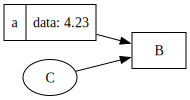

In [2]:
dot = Digraph(graph_attr={'rankdir': 'LR'})
dot.node('B', shape='record')
dot.node(name='A', label = '{a | data: 4.23}', shape='record')
dot.node('C')
dot.edge('A','B')
dot.edge('C','B')
dot

In [3]:
def trace(root : Value):
    nodes = set()
    edges = set()

    # use DFS, DAG so keep going till all edges explored.
    nodes.add(root)
    for child in root._prev:
        edges.add((child, root))
        n, e = trace(child)
        nodes.update(n)
        edges.update(e)

    return nodes, edges


def draw_dot(root):
    dot = Digraph(
        graph_attr={'rankdir':'LR'}
    )

    nodes, edges = trace(root)

    for n in nodes:
        dot.node(name=str(id(n)), label="{ %s | data: %.4f | grad: %.4f}" % (n.label, n.data, n.grad), shape='record')
        # if op node, create one
        if n._op != '':
            dot.node(name = str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))
    for a, b in edges:
        dot.edge(str(id(a)), str(id(b)) + b._op)

    return dot

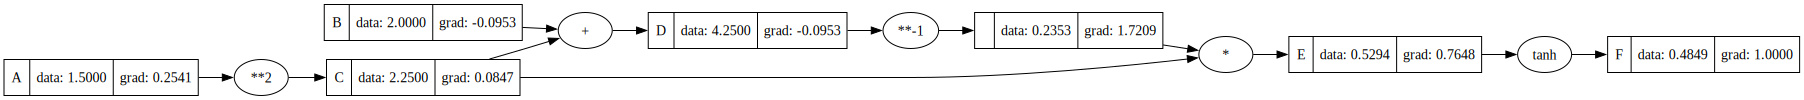

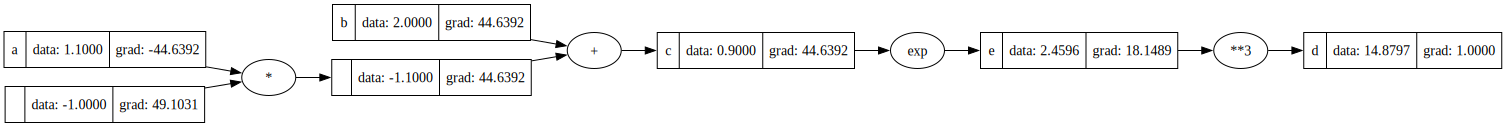

In [54]:


a = Value(1.1) ; a.label = 'a'
b = Value(2.0) ; b.label = 'b'
c = b - a ; c.label = 'c'
e = c.exp(); e.label = 'e'
d = e**3 ; d.label = 'd'

d.backward()
draw_dot(d)

In [55]:
# testing grads
h = 0.0000001

a = Value(1.1) + h; a.label = 'a'
b = Value(2.0) ; b.label = 'b'
c = b - a; c.label = 'c'
e = c.exp(); e.label = 'e'
d1 = e**3 ; d.label = 'd'
print((d1.data - d.data) / h)

-44.639188470085855
